<a href="https://colab.research.google.com/github/UNSW-ZZSC9020/project/blob/main/src/GoogleColab.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Welcome to ZZSC9020

This Python notebook shows how to clone the course GitHub repository on Google Colab.

You can develop your data analysis on Google Colab without downloading the data to your computer.

In [1]:
# This will remove all user-defined variables from the workspace
%reset -f

In [2]:
#clone
!rm -rf zzsc9020-teamc data
!git clone https://github.com/t-frank-unsw/zzsc9020-teamc.git
#check files
!ls -la zzsc9020-teamc/data/NSW/
#make folder
!mkdir -p data
!cat zzsc9020-teamc/data/NSW/forecastdemand_nsw.csv.zip.part* > data/forecastdemand_nsw.csv.zip
#unzip files
!unzip data/forecastdemand_nsw.csv.zip -d data
!unzip zzsc9020-teamc/data/NSW/temperature_nsw.csv.zip -d data
!unzip zzsc9020-teamc/data/NSW/totaldemand_nsw.csv.zip -d data
#clean
!rm data/forecastdemand_nsw.csv.zip
#check
!ls -lh data/

Cloning into 'zzsc9020-teamc'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 230 (delta 38), reused 22 (delta 22), pack-reused 183 (from 4)
Receiving objects: 100% (230/230), 221.05 MiB | 19.72 MiB/s, done.
Resolving deltas: 100% (76/76), done.
total 237792
drwxr-xr-x@ 6 liammitrodobson  staff        192 Oct  4 12:48 .
drwxr-xr-x@ 3 liammitrodobson  staff         96 Oct  4 12:48 ..
-rw-r--r--@ 1 liammitrodobson  staff  104857600 Oct  4 12:48 forecastdemand_nsw.csv.zip.partaa
-rw-r--r--@ 1 liammitrodobson  staff   14669007 Oct  4 12:48 forecastdemand_nsw.csv.zip.partab
-rw-r--r--@ 1 liammitrodobson  staff     920562 Oct  4 12:48 temperature_nsw.csv.zip
-rw-r--r--@ 1 liammitrodobson  staff    1296200 Oct  4 12:48 totaldemand_nsw.csv.zip
Archive:  data/forecastdemand_nsw.csv.zip
  inflating: data/forecastdemand_nsw.csv  
Archive:  zzsc9020-teamc/data/NSW/temperature_nsw.csv.zip
  infla

In [3]:
# Import any packages
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import plot_tree
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, train_test_split
import holidays
from pyexpat import features

# Get NSW public holidays
nsw_holidays = holidays.country_holidays('AU', subdiv='NSW')

import pandas as pd, numpy as np, matplotlib.pyplot as plt

PATH_FORECAST = "data/forecastdemand_nsw.csv"
PATH_TEMP     = "data/temperature_nsw.csv"
PATH_ACTUAL   = "data/totaldemand_nsw.csv"

def dt_dayfirst(s):
    return pd.to_datetime(s, errors="coerce", dayfirst=True)

def dt_us(s):
    s = s.astype(str).str.strip().str.replace(r"(\d{1,2})/(\d{1,2})/(\d{2})(?!\d)", r"\1/\2/20\3", regex=True)
    return pd.to_datetime(s, errors="coerce", dayfirst=False)

#daily actual peak
a = (pd.read_csv(PATH_ACTUAL, usecols=["DATETIME","TOTALDEMAND","REGIONID"])
      .query("REGIONID=='NSW1'").drop(columns="REGIONID"))
a["DATETIME"] = dt_dayfirst(a["DATETIME"])
a["ACTUAL"] = pd.to_numeric(a["TOTALDEMAND"], errors="coerce")
a = a.dropna(subset=["DATETIME","ACTUAL"])
a["DATE"] = a["DATETIME"].dt.floor("D")
daily_actual = a.groupby("DATE", as_index=False)["ACTUAL"].max().rename(columns={"ACTUAL":"ACTUAL_PEAK"})

#daily max and min temp
t = pd.read_csv(PATH_TEMP).rename(columns={"TemperatureTEMPERATURE":"TEMPERATURE"})
t["DATETIME"] = dt_dayfirst(t["DATETIME"])
t["TEMPERATURE"] = pd.to_numeric(t["TEMPERATURE"], errors="coerce")
t = t.dropna(subset=["DATETIME","TEMPERATURE"])
t["DATE"] = t["DATETIME"].dt.floor("D")
daily_temp = (
    t.groupby("DATE", as_index=False)["TEMPERATURE"]
    .agg(["max", "min", "mean"])
    .rename(columns={"max": "TEMP_MAX", "min": "TEMP_MIN", "mean": "TEMP_MEAN"})
    .reset_index()
)

#forecast max energy demand from day before
f = (pd.read_csv(PATH_FORECAST, usecols=["DATETIME","FORECASTDEMAND","REGIONID","LASTCHANGED"])
      .query("REGIONID=='NSW1'").drop(columns="REGIONID"))
f["DATETIME"]    = dt_us(f["DATETIME"])
f["LASTCHANGED"] = dt_us(f["LASTCHANGED"])
f["FORECASTDEMAND"] = pd.to_numeric(f["FORECASTDEMAND"], errors="coerce")
f = f.dropna(subset=["DATETIME","LASTCHANGED","FORECASTDEMAND"])
f["DATE_TARGET"] = f["DATETIME"].dt.floor("D")
f["DATE_ISSUE"]  = f["LASTCHANGED"].dt.floor("D")
f_day_ahead = f.loc[f["DATE_ISSUE"].eq(f["DATE_TARGET"] - pd.Timedelta(days=1))]
daily_forecast = (f_day_ahead.groupby("DATE_TARGET", as_index=False)["FORECASTDEMAND"]
                  .max().rename(columns={"DATE_TARGET":"DATE","FORECASTDEMAND":"FORECAST_PEAK"}))

#merge
daily = (daily_actual.merge(daily_temp, on="DATE", how="left")
                     .merge(daily_forecast, on="DATE", how="left"))
daily["ERROR"] = daily["ACTUAL_PEAK"] - daily["FORECAST_PEAK"]
daily["YEAR"]  = daily["DATE"].dt.year

#add extreme temperature flags
daily["IS_EXTREME_HOT"] = (daily["TEMP_MAX"] > 35).astype(bool)   #extreme hot day = max temp > 35 deg C
daily["IS_EXTREME_COLD"] = (daily["TEMP_MIN"] < 5).astype(bool)   #extreme cold day = min temp < 5 deg C
daily["IS_TEMP_EXTREME"] = ((daily["IS_EXTREME_HOT"] == 1) | (daily["IS_EXTREME_COLD"] == 1)).astype(bool)

In [4]:
daily.head()

,DATE,ACTUAL_PEAK,index,TEMP_MAX,TEMP_MIN,TEMP_MEAN,FORECAST_PEAK,ERROR,YEAR,IS_EXTREME_HOT,IS_EXTREME_COLD,IS_TEMP_EXTREME
0,2010-01-01,8883.98,0.0,28.8,22.1,25.094000,9203.56,-319.58,2010,False,False,False
1,2010-01-02,9294.07,1.0,29.4,21.6,24.765385,9035.95,258.12,2010,False,False,False
2,2010-01-03,8247.61,2.0,21.5,17.9,19.429825,8427.68,-180.07,2010,False,False,False
3,2010-01-04,9468.92,3.0,23.9,17.9,20.625926,10200.10,-731.18,2010,False,False,False
4,2010-01-05,10687.29,4.0,27.7,15.4,22.660417,10750.37,-63.08,2010,False,False,False


In [5]:

hot_mask = daily['IS_EXTREME_HOT'].astype(bool)
cold_mask = daily['IS_EXTREME_COLD'].astype(bool)

masks = {
    'Extreme Hot Days': hot_mask,
    'Extreme Cold Days': cold_mask,
}

print('-----------------------------------')

print('Number of Extreme Hot Days:', hot_mask.sum(), f"({hot_mask.sum()/len(daily)*100:.2f}%)")
print('Number of Extreme Cold Days:', cold_mask.sum(), f"({cold_mask.sum()/len(daily)*100:.2f}%)")

# Calculate MSE and R2 for each category

results = {}
for label, mask in masks.items():
    mse = mean_squared_error(daily[mask]['ACTUAL_PEAK'], daily[mask]['FORECAST_PEAK'])
    r2 = r2_score(daily[mask]['ACTUAL_PEAK'], daily[mask]['FORECAST_PEAK'])
    results[label] = {'MSE': mse, 'R2': r2}

print('-----------------------------------')
for label, metrics in results.items():
    print(f"Base Model - {label} MSE: {metrics['MSE']}")
print('-----------------------------------')
for label, metrics in results.items():
    print(f"Base Model - {label} R2: {metrics['R2']}")
print('-----------------------------------')


-----------------------------------
Number of Extreme Hot Days: 76 (1.86%)
Number of Extreme Cold Days: 355 (8.67%)
-----------------------------------
Base Model - Extreme Hot Days MSE: 252331.48489736844
Base Model - Extreme Cold Days MSE: 50637.990120845134
-----------------------------------
Base Model - Extreme Hot Days R2: 0.8472073067467959
Base Model - Extreme Cold Days R2: 0.9246822615024998
-----------------------------------


In [6]:
#prep features
d = daily.copy().sort_values("DATE").reset_index(drop=True)
#drop rows with missing target, TEMP_MAX, or TEMP_MIN
d = d.dropna(subset=["ACTUAL_PEAK","TEMP_MAX","TEMP_MIN"]).reset_index(drop=True)

#feature engineering
d["FORECAST_PEAK"] = d["FORECAST_PEAK"].fillna(method="ffill").fillna(d["ACTUAL_PEAK"].median())

# Add day of week and month 
d['DAYOFWEEK'] = d['DATE'].dt.dayofweek
d['MONTH'] = d['DATE'].dt.month
# calendar features
d['DOY'] = d['DATE'].dt.dayofyear
# cyclical encoding for day of year
d['DOY_SIN'] = np.sin(2 * np.pi * d['DOY'] / 365.25)
d['DOY_COS'] = np.cos(2 * np.pi * d['DOY'] / 365.25)
d['IS_HOLIDAY'] = d['DATE'].dt.date.apply(lambda x: bool(x in nsw_holidays))
d['IS_WEEKEND'] = d['DAYOFWEEK'].apply(lambda x: True if x >= 5 else False)

for lag in [1, 2, 3]:
    d[f'ACTUAL_PEAK_LAG{lag}'] = d['ACTUAL_PEAK'].shift(lag)
    d[f'TEMP_MEAN_LAG{lag}'] = d['TEMP_MEAN'].shift(lag)
    d[f'TEMP_MAX_LAG{lag}'] = d['TEMP_MAX'].shift(lag)
    d[f'TEMP_MIN_LAG{lag}'] = d['TEMP_MIN'].shift(lag)
    d[f"FORECAST_LAG{lag}"] = d['FORECAST_PEAK'].shift(lag)

# Temperature difference feature 
d['TEMP_DIFF'] = d['TEMP_MAX'] - d['TEMP_MIN']
   
# Non-linear features
d['TEMP_MAX_SQ'] = d['TEMP_MAX'] ** 2
d['TEMP_MAX_CU'] = d['TEMP_MAX'] ** 3

# Rolling 3 averages
d['TEMP_MAX_ROLL3'] = d['TEMP_MAX'].shift(1).rolling(3, min_periods=1).mean()
d['TEMP_MIN_ROLL3'] = d['TEMP_MIN'].shift(1).rolling(3, min_periods=1).mean()
d['FORECAST_ROLL3']  = d['FORECAST_PEAK'].shift(1).rolling(3, min_periods=1).mean()

# interaction features
d['TEMP_MAX_X_IS_HOLIDAY'] = d['TEMP_MAX'] * d['IS_HOLIDAY']
d['TEMP_MAX_X_IS_WEEKEND'] = d['TEMP_MAX'] * d['IS_WEEKEND']
d['TEMP_MAX_X_IS_EXTREME_HOT'] = d['TEMP_MAX'] * d['IS_EXTREME_HOT']
d['TEMP_MAX_X_TEMP_MIN'] = d['TEMP_MAX'] * d['TEMP_MIN']
d['TEMP_MAX_X_TEMP_DIFF'] = d['TEMP_MAX'] * d['TEMP_DIFF']

d = pd.get_dummies(d, columns=['DAYOFWEEK', 'MONTH'])

d = d.dropna().reset_index(drop=True)  # drop rows with any NA from lags
y = d["ACTUAL_PEAK"].values

# Feature matrix X and target y
feature_cols = [
    # temporal features
    'TEMP_MEAN', 'TEMP_MIN', 'TEMP_MAX','TEMP_DIFF',
    
    'TEMP_MAX_ROLL3', 'TEMP_MIN_ROLL3',
    
    'TEMP_MAX_LAG1', 'TEMP_MAX_LAG2', 'TEMP_MAX_LAG3',
    'TEMP_MIN_LAG1', 'TEMP_MIN_LAG2', 'TEMP_MIN_LAG3',
    
    # TEMP_EXTREME features
    'IS_EXTREME_HOT', 'IS_EXTREME_COLD', 'IS_TEMP_EXTREME',
    
    # CALENDAR features
     'IS_HOLIDAY', 'IS_WEEKEND',

    # FORECAST AND PREVIOUS DAY ACTUAL
    'FORECAST_PEAK',
    'FORECAST_LAG1', 'FORECAST_LAG2', 'FORECAST_LAG3',
    'FORECAST_ROLL3',
    
] + [
    col for col in d.columns if 
    # one-hot encoded features
    col.startswith('DAYOFWEEK_') or 
    col.startswith('MONTH_')
]
X = d[feature_cols]  # drop rows with any NA from lags
# Combine X and y into a single DataFrame, drop NAs, then split again
df_xy = X.copy()
df_xy['ACTUAL_PEAK'] = y
df_xy = df_xy.dropna().reset_index(drop=True)
X_clean = df_xy.drop(columns=['ACTUAL_PEAK'])
y_clean = df_xy['ACTUAL_PEAK']
len(X_clean), len(y_clean)  # Check lengths match after dropping NA
X= X_clean
y= y_clean


/var/folders/vj/fr9bcrcs0hb0hf6wgnp2r7fc0000gn/T/ipykernel_24826/1166075977.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  d["FORECAST_PEAK"] = d["FORECAST_PEAK"].fillna(method="ffill").fillna(d["ACTUAL_PEAK"].median())


In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Set up TimeSeriesSplit (e.g., 4 splits)
tscv = TimeSeriesSplit(n_splits=4)

# sample weights to focus the model on extremes - upweight extreme temps
alpha = 3.0
temp_med = X_train['TEMP_MAX'].median()
temp_iqr = X_train['TEMP_MAX'].quantile(0.75) - X_train['TEMP_MAX'].quantile(0.25) or 1.0
# distance measure
dist = np.abs(X_train['TEMP_MAX'] - temp_med) / temp_iqr
sample_weight = 1.0 + alpha * (dist/ (dist.max() if dist.max() != 0 else 1.0))
# ensure extremes flagged strongly
sample_weight = sample_weight * (1.0 + 2.0 * (X_train['IS_TEMP_EXTREME']))

# RandomizedSearchCV for XGBoost
xgb_model = xgb.XGBRegressor()
param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 1, 5],
    "min_child_weight": [2, 4, 8],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2],
}
random_search = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions,
    n_iter=50,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1, 
    verbose=1,
)

# Best model
random_search.fit(X_train, y_train,sample_weight=sample_weight.values)
best_model = random_search.best_estimator_
best_model.fit(X_train, y_train,sample_weight=sample_weight.values)


Fitting 4 folds for each of 50 candidates, totalling 200 fits


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=8, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [12]:
#predict
pred_train = best_model.predict(X_train)
pred_test = best_model.predict(X_test)
pred_all = best_model.predict(X)
#attach predictions and residuals to X
d["PRED_XGB"] = pred_all
d["RESID_XGB"] = d["ACTUAL_PEAK"] - d["PRED_XGB"]
d["RESID_FORECAST"] = d["ACTUAL_PEAK"] - d["FORECAST_PEAK"]
print("Best Params:", random_search.best_params_)
d['RESID_FORECAST_PEAK'] = d['ACTUAL_PEAK'] - d['FORECAST_PEAK']
d['RESID_XGB'] = d['ACTUAL_PEAK'] - d['PRED_XGB']
#metrics to measure model effectiveness (mae, rmse)
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    #r squared
    r2 = r2_score(y_true, y_pred)
    return {"MAE":mae, "RMSE":rmse, "MAPE_pct":mape, "R2":r2}
# Evaluate on all data
metrics_forecast_all_data = metrics(d["ACTUAL_PEAK"].values, d["FORECAST_PEAK"].values)
metrics_xgb_all_data = metrics(d["ACTUAL_PEAK"].values, d["PRED_XGB"].values)
# Evaluate on train and test sets
metrics_xgb_train = metrics(y_train, pred_train)
metrics_xgb_test = metrics(y_test, pred_test)
print("Forecast (24h) on ALL data:", metrics_forecast_all_data)
print('--------------------------------')
print("XGBoost on ALL data:", metrics_xgb_all_data)
print("XGBoost on TRAIN:", metrics_xgb_train)
print("XGBoost on TEST:", metrics_xgb_test)
#calculate improvement
mae_improvement = metrics_forecast_all_data["MAE"] - metrics_xgb_all_data["MAE"]
rmse_improvement = metrics_forecast_all_data["RMSE"] - metrics_xgb_all_data["RMSE"]
r2_improvement = metrics_xgb_all_data["R2"] - metrics_forecast_all_data["R2"]
print(f"\nMAE improvement: {mae_improvement:.1f} MW ({mae_improvement/metrics_forecast_all_data['MAE']*100:.1f}%)")
print(f"RMSE improvement: {rmse_improvement:.1f} MW ({rmse_improvement/metrics_forecast_all_data['RMSE']*100:.1f}%)")
print(f"R² improvement: {r2_improvement:.3f} ({r2_improvement/metrics_forecast_all_data['R2']*100:.1f}%)")

d.head()


Best Params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 8, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Forecast (24h) on ALL data: {'MAE': 216.4398337001712, 'RMSE': 293.2432346091219, 'MAPE_pct': np.float64(2.23760666693388), 'R2': 0.9401868862073843}
--------------------------------
XGBoost on ALL data: {'MAE': 112.36327266179077, 'RMSE': 160.77776128259737, 'MAPE_pct': np.float64(1.1781031092155383), 'R2': 0.9820198892123086}
XGBoost on TRAIN: {'MAE': 89.53531143118502, 'RMSE': 117.92544313157069, 'MAPE_pct': np.float64(0.9487847980823838), 'R2': 0.9902309470974163}
XGBoost on TEST: {'MAE': 203.64721054114455, 'RMSE': 271.3064719533719, 'MAPE_pct': np.float64(2.095096013514498), 'R2': 0.9507226796889104}

MAE improvement: 104.1 MW (48.1%)
RMSE improvement: 132.5 MW (45.2%)
R² improvement: 0.042 (4.4%)


,DATE,ACTUAL_PEAK,index,TEMP_MAX,TEMP_MIN,TEMP_MEAN,FORECAST_PEAK,ERROR,YEAR,IS_EXTREME_HOT,...,MONTH_7,MONTH_8,MONTH_9,MONTH_10,MONTH_11,MONTH_12,PRED_XGB,RESID_XGB,RESID_FORECAST,RESID_FORECAST_PEAK
0,2010-01-04,9468.92,3.0,23.9,17.9,20.625926,10200.10,-731.18,2010,False,...,False,False,False,False,False,False,9601.680664,-132.760664,-731.18,-731.18
1,2010-01-05,10687.29,4.0,27.7,15.4,22.660417,10750.37,-63.08,2010,False,...,False,False,False,False,False,False,10559.386719,127.903281,-63.08,-63.08
2,2010-01-06,10879.15,5.0,25.6,20.3,22.679592,10707.74,171.41,2010,False,...,False,False,False,False,False,False,10684.871094,194.278906,171.41,171.41
3,2010-01-07,9864.35,6.0,23.6,20.5,21.879167,10167.83,-303.48,2010,False,...,False,False,False,False,False,False,9894.535156,-30.185156,-303.48,-303.48
4,2010-01-08,10659.19,7.0,26.3,19.7,22.878846,10783.25,-124.06,2010,False,...,False,False,False,False,False,False,10668.654297,-9.464297,-124.06,-124.06


Max Temperature Analysis:


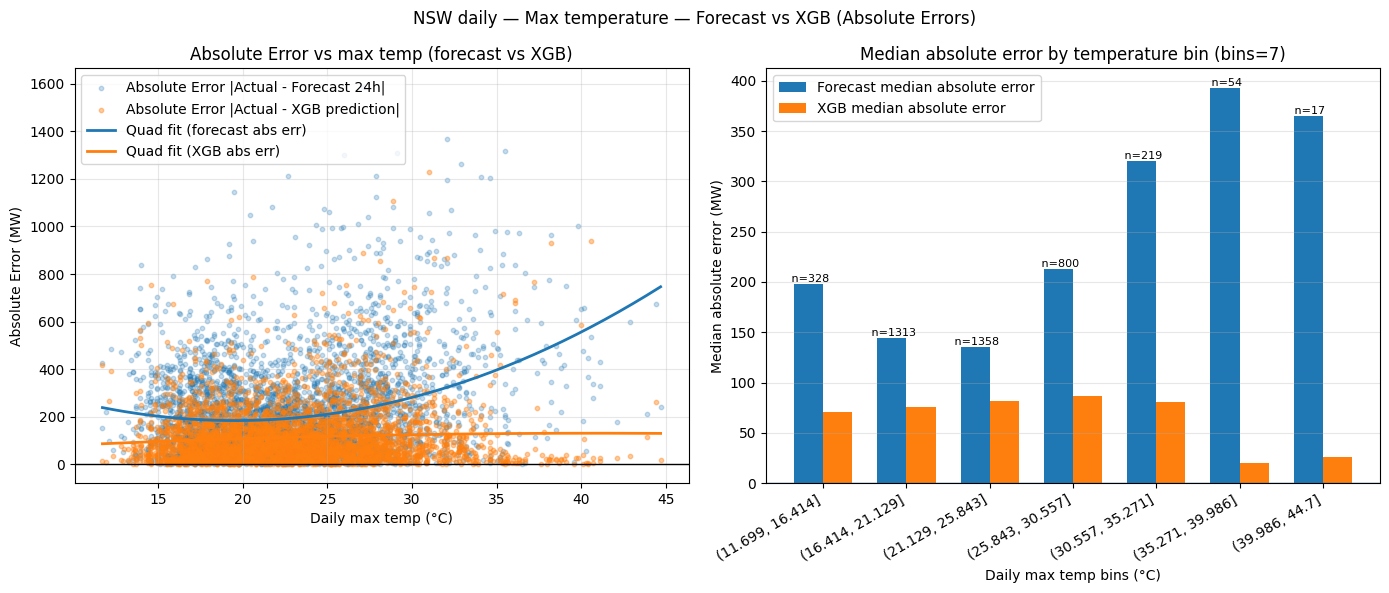


Min Temperature Analysis:


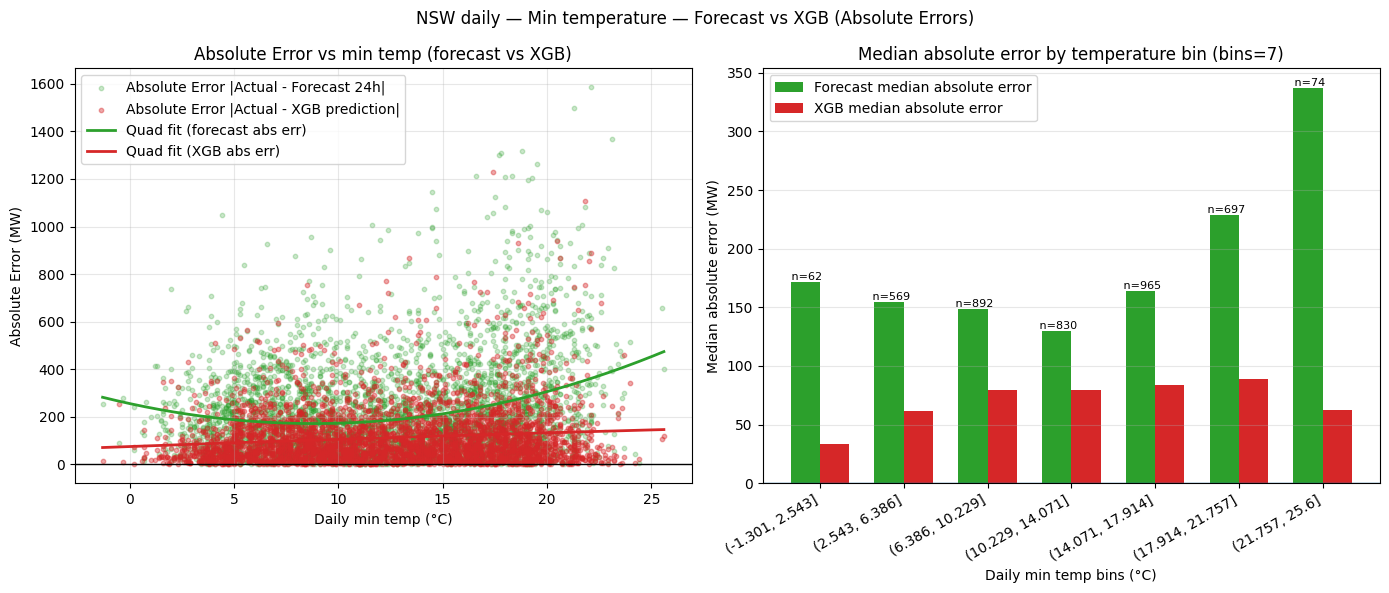


Extreme Weather Conditions Analysis:


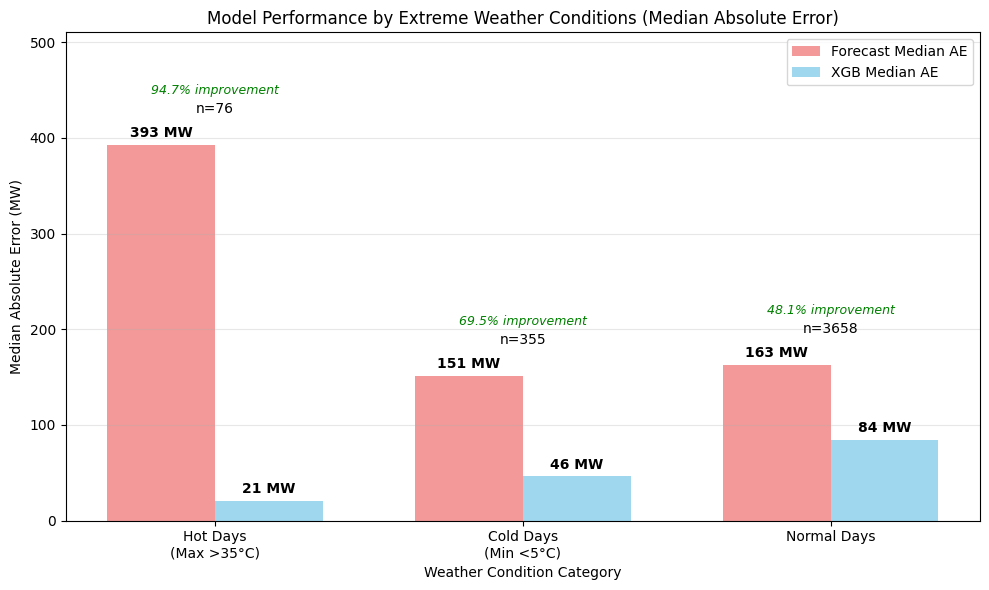


Extreme Weather Performance Summary (Median Absolute Error):
Hot Days
(Max >35°C): 76 days, Forecast: 392.7 MW, XGB: 20.8 MW, Improvement: 94.7%
Cold Days
(Min <5°C): 355 days, Forecast: 151.1 MW, XGB: 46.1 MW, Improvement: 69.5%
Normal Days: 3658 days, Forecast: 162.6 MW, XGB: 84.4 MW, Improvement: 48.1%
Feature importances (top 10):
IS_TEMP_EXTREME    0.563717
FORECAST_PEAK      0.128246
IS_EXTREME_HOT     0.114369
FORECAST_LAG1      0.040017
DAYOFWEEK_5        0.021172
IS_WEEKEND         0.019339
TEMP_MEAN          0.017503
DAYOFWEEK_0        0.016494
DAYOFWEEK_6        0.012980
FORECAST_LAG2      0.008687
dtype: float32

Improvement by temperature extremes:
Hot days (max >35°C): {'n': 76, 'forecast_MAE': 412.73315789473685, 'forecast_R2': 0.8472073067467959, 'forecast_RMSE': 502.32607427583173, 'xgb_MAE': 102.68002467105278, 'xgb_R2': 0.9641400761022924, 'xgb_RMSE': 243.35434811877474, 'MAE_reduction': 310.0531332236841, 'R2_improvement': 0.11693276935549646, 'RMSE_improvement': 2

In [13]:
def plot_compare_xgb_max_temp(dframe, year=None, bins=7):
    dd = dframe.loc[dframe["YEAR"].eq(year)] if year is not None else dframe
    dd = dd.dropna(subset=["TEMP_MAX","RESID_FORECAST_PEAK","RESID_XGB"]).copy()
    if dd.empty:
        print("No data")
        return
    x = dd["TEMP_MAX"].to_numpy()
    e_fc = np.abs(dd["RESID_FORECAST_PEAK"].to_numpy())
    e_xgb = np.abs(dd["RESID_XGB"].to_numpy())
    
    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)
    
    xg_fc, e_fit_fc = quad_fit(x, e_fc)
    xg_xgb, e_fit_xgb = quad_fit(x, e_xgb)
    
    fig, axs = plt.subplots(1,2, figsize=(14,6))
    
    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Absolute Error |Actual - Forecast 24h|", color="C0")
    axs[0].scatter(x, e_xgb, alpha=0.4, s=10, label="Absolute Error |Actual - XGB prediction|", color="C1")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C0", label="Quad fit (forecast abs err)")
    if xg_xgb.size: axs[0].plot(xg_xgb, e_fit_xgb, linewidth=2, color="C1", label="Quad fit (XGB abs err)")
    axs[0].set_xlabel("Daily max temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs max temp (forecast vs XGB)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)
    
    edges = np.linspace(dd["TEMP_MAX"].min(), dd["TEMP_MAX"].max(), bins+1)
    dd = dd.assign(TEMP_BIN=pd.cut(dd["TEMP_MAX"], bins=edges, include_lowest=True),
                ABS_RESID_FORECAST=np.abs(dd["RESID_FORECAST_PEAK"]),
                ABS_RESID_XGB=np.abs(dd["RESID_XGB"]))
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(med_err_fc=("ABS_RESID_FORECAST","median"),
                    count=("ABS_RESID_FORECAST","size")).reset_index()
    g_xgb = dd.groupby("TEMP_BIN", observed=True).agg(med_err_xgb=("ABS_RESID_XGB","median")).reset_index()
    
    g = g_fc.merge(g_xgb, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median absolute error")
    axs[1].bar(idx + width/2, g["med_err_xgb"], width=width, label="XGB median absolute error")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily max temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, xgbv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_xgb"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)
    
    plt.suptitle(f"NSW daily — Max temperature{' ('+str(year)+')' if year else ''} — Forecast vs XGB (Absolute Errors)")
    plt.tight_layout(); plt.show()

#min temp plots
def plot_compare_xgb_min_temp(dframe, year=None, bins=7):
    dd = dframe.loc[dframe["YEAR"].eq(year)] if year is not None else dframe
    dd = dd.dropna(subset=["TEMP_MIN","RESID_FORECAST_PEAK","RESID_XGB"]).copy()
    if dd.empty:
        print("No data")
        return
    x = dd["TEMP_MIN"].to_numpy()
    e_fc = np.abs(dd["RESID_FORECAST_PEAK"].to_numpy())
    e_xgb = np.abs(dd["RESID_XGB"].to_numpy())
    
    def quad_fit(x, y, n=200):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 3: return np.array([]), np.array([])
        xm, xs = x[m].mean(), (x[m].std() or 1.0)
        coef = np.polyfit((x[m]-xm)/xs, y[m], deg=2)
        xg = np.linspace(x[m].min(), x[m].max(), n)
        return xg, np.polyval(coef, (xg-xm)/xs)
    
    xg_fc, e_fit_fc = quad_fit(x, e_fc)
    xg_xgb, e_fit_xgb = quad_fit(x, e_xgb)
    
    fig, axs = plt.subplots(1,2, figsize=(14,6))
    
    axs[0].axhline(0, linewidth=1, color="k")
    axs[0].scatter(x, e_fc, alpha=0.25, s=10, label="Absolute Error |Actual - Forecast 24h|", color="C2")
    axs[0].scatter(x, e_xgb, alpha=0.4, s=10, label="Absolute Error |Actual - XGB prediction|", color="C3")
    if xg_fc.size: axs[0].plot(xg_fc, e_fit_fc, linewidth=2, color="C2", label="Quad fit (forecast abs err)")
    if xg_xgb.size: axs[0].plot(xg_xgb, e_fit_xgb, linewidth=2, color="C3", label="Quad fit (XGB abs err)")
    axs[0].set_xlabel("Daily min temp (°C)"); axs[0].set_ylabel("Absolute Error (MW)")
    axs[0].set_title("Absolute Error vs min temp (forecast vs XGB)")
    axs[0].legend(); axs[0].grid(True, alpha=0.3)
    
    edges = np.linspace(dd["TEMP_MIN"].min(), dd["TEMP_MIN"].max(), bins+1)
    dd = dd.assign(TEMP_BIN=pd.cut(dd["TEMP_MIN"], bins=edges, include_lowest=True),
            ABS_RESID_FORECAST=np.abs(dd["RESID_FORECAST_PEAK"]),
            ABS_RESID_XGB=np.abs(dd["RESID_XGB"]))
    g_fc = dd.groupby("TEMP_BIN", observed=True).agg(med_err_fc=("ABS_RESID_FORECAST","median"),
                count=("ABS_RESID_FORECAST","size")).reset_index()
    g_xgb = dd.groupby("TEMP_BIN", observed=True).agg(med_err_xgb=("ABS_RESID_XGB","median")).reset_index()
    
    g = g_fc.merge(g_xgb, on="TEMP_BIN")
    idx = np.arange(len(g))
    width = 0.35
    axs[1].bar(idx - width/2, g["med_err_fc"], width=width, label="Forecast median absolute error", color="C2")
    axs[1].bar(idx + width/2, g["med_err_xgb"], width=width, label="XGB median absolute error", color="C3")
    axs[1].axhline(0, linewidth=1)
    axs[1].set_xticks(idx); axs[1].set_xticklabels(g["TEMP_BIN"].astype(str), rotation=30, ha="right")
    axs[1].set_xlabel("Daily min temp bins (°C)"); axs[1].set_ylabel("Median absolute error (MW)")
    axs[1].set_title(f"Median absolute error by temperature bin (bins={bins})")
    for i, (fcv, xgbv, cnt) in enumerate(zip(g["med_err_fc"], g["med_err_xgb"], g["count"])):
        axs[1].text(i - width/2, fcv, f" n={cnt}", ha="center", va="bottom", fontsize=8)
    axs[1].legend(); axs[1].grid(True, axis="y", alpha=0.3)
    
    plt.suptitle(f"NSW daily — Min temperature{' ('+str(year)+')' if year else ''} — Forecast vs XGB (Absolute Errors)")
    plt.tight_layout(); plt.show()
    
#extreme weather performance plot to measure effectiveness of model on extreme hot day and extreme cold day
def plot_extreme_weather_performance(dframe):
    """Plot performance specifically for extreme hot and cold days using MEDIAN"""
    # Filter data
    hot_days = dframe.loc[dframe["IS_EXTREME_HOT"] == 1] #extreme hot day = max temp > 35 deg C
    cold_days = dframe.loc[dframe["IS_EXTREME_COLD"] == 1] #extreme cold day = min temp < 5 deg C
    normal_days = dframe.loc[(dframe["IS_EXTREME_HOT"] == 0) & (dframe["IS_EXTREME_COLD"] == 0)]
    
    def get_median_ae(subset, pred_col):
        if len(subset) == 0:
            return 0, 0
        median_ae = np.median(np.abs(subset["ACTUAL_PEAK"] - subset[pred_col]))
        return median_ae, len(subset)
    
    #calc mae
    categories = ['Hot Days\n(Max >35°C)', 'Cold Days\n(Min <5°C)', 'Normal Days']
    datasets = [hot_days, cold_days, normal_days]
    
    forecast_medians = []
    xgb_medians = []
    sample_sizes = []
    
    for dataset in datasets:
        fc_median, n = get_median_ae(dataset, "FORECAST_PEAK")
        xgb_median, _ = get_median_ae(dataset, "PRED_XGB")
        forecast_medians.append(fc_median)
        xgb_medians.append(xgb_median)
        sample_sizes.append(n)
    
    #plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.set_ylim(0, max(forecast_medians + xgb_medians) * 1.3)
    
    x = np.arange(len(categories))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, forecast_medians, width, label='Forecast Median AE', color='lightcoral', alpha=0.8)
    bars2 = ax.bar(x + width/2, xgb_medians, width, label='XGB Median AE', color='skyblue', alpha=0.8)
    
    #add value labels on bars
    for i, (fc_median, xgb_median, n) in enumerate(zip(forecast_medians, xgb_medians, sample_sizes)):
        #forecast bar
        ax.text(i - width/2, fc_median + 5, f'{fc_median:.0f} MW', ha='center', va='bottom', fontweight='bold')
        #xgb bar
        ax.text(i + width/2, xgb_median + 5, f'{xgb_median:.0f} MW', ha='center', va='bottom', fontweight='bold')
        #sample size
        ax.text(i, max(fc_median, xgb_median) + 30, f'n={n}'
        , ha='center', va='bottom', fontsize=10)
        #improvement percentage
        if fc_median > 0:
            improvement = ((fc_median - xgb_median) / fc_median) * 100
            ax.text(i, max(fc_median, xgb_median) + 50, f'{improvement:.1f}% improvement',
                    ha='center', va='bottom', fontsize=9, style='italic', color='green')
    ax.set_xlabel('Weather Condition Category')
    ax.set_ylabel('Median Absolute Error (MW)')
    ax.set_title('Model Performance by Extreme Weather Conditions (Median Absolute Error)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    #print detailed results
    print("\nExtreme Weather Performance Summary (Median Absolute Error):")
    for i, (cat, fc_median, xgb_median, n) in enumerate(zip(categories, forecast_medians, xgb_medians, sample_sizes)):
        improvement = ((fc_median - xgb_median) / fc_median) * 100 if fc_median > 0 else 0
        print(f"{cat}: {n} days, Forecast: {fc_median:.1f} MW, XGB: {xgb_median:.1f} MW, Improvement: {improvement:.1f}%")
    
#generate all plots
print("Max Temperature Analysis:")
plot_compare_xgb_max_temp(d)
print("\nMin Temperature Analysis:")
plot_compare_xgb_min_temp(d)
print("\nExtreme Weather Conditions Analysis:")
plot_extreme_weather_performance(d)

#feature importances
fi = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Feature importances (top 10):")
print(fi.head(10))
    
#quantifying improvement by temperature extremes
def improvement_by_temp_extremes(dframe):
    hot = dframe.loc[dframe["IS_EXTREME_HOT"] == 1] #extreme hot day = max temp > 35 deg C
    cold = dframe.loc[dframe["IS_EXTREME_COLD"] == 1] #extreme cold day = min temp < 5 deg C
    normal = dframe.loc[(dframe["IS_EXTREME_HOT"] == 0) & (dframe["IS_EXTREME_COLD"] == 0)]
    
    def comp(sub, label):
        if len(sub)==0: return {}
        fc = metrics(sub["ACTUAL_PEAK"].values, sub["FORECAST_PEAK"].values)
        xgb = metrics(sub["ACTUAL_PEAK"].values, sub["PRED_XGB"].values)
        return {label: {"n":len(sub),
                "forecast_MAE":fc["MAE"], "forecast_R2":fc["R2"], "forecast_RMSE":fc["RMSE"],
                "xgb_MAE":xgb["MAE"], "xgb_R2":xgb["R2"], "xgb_RMSE":xgb["RMSE"],
                "MAE_reduction": fc["MAE"]-xgb["MAE"], "R2_improvement": xgb["R2"]-fc["R2"], "RMSE_improvement": fc["RMSE"]-xgb["RMSE"]
                }
        }
        
    print("\nImprovement by temperature extremes:")
    result = {}
    result.update(comp(hot, "Hot days (max >35°C)"))
    result.update(comp(cold, "Cold days (min <5°C)"))
    result.update(comp(normal, "Normal days"))

    for key, values in result.items():
        print(f"{key}: {values}")
    
improvement_by_temp_extremes(d)

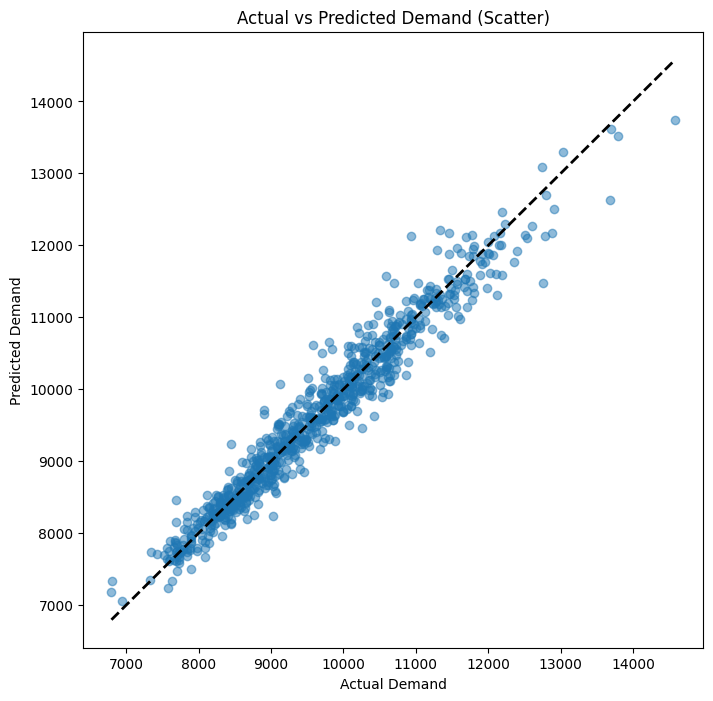

<Figure size 1000x800 with 0 Axes>

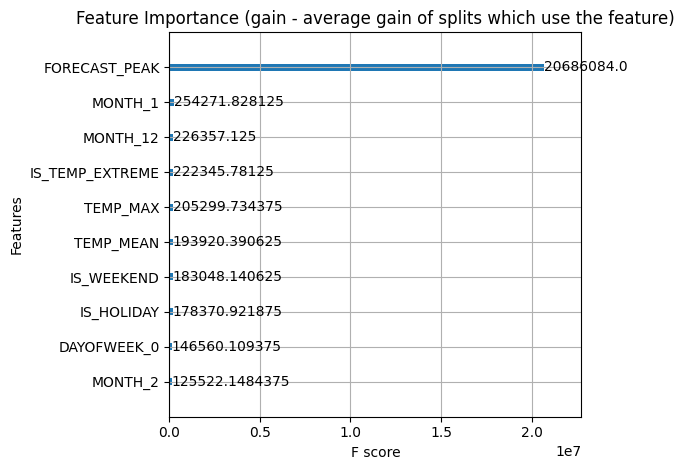

<Figure size 1000x800 with 0 Axes>

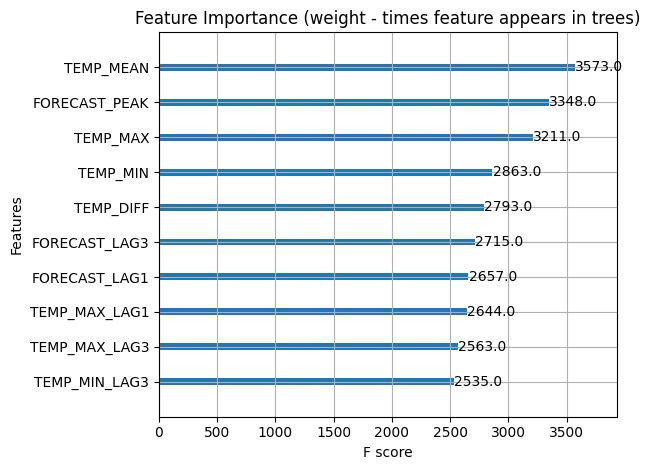

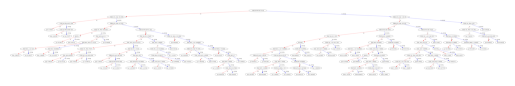

In [10]:
# Scatter plot of actual vs predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, pred_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Demand')
plt.ylabel('Predicted Demand')
plt.title('Actual vs Predicted Demand (Scatter)')
plt.show()
# Gain importance which measures the average gain of splits which use the feature
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, importance_type='gain', max_num_features=10)
plt.title('Feature Importance (gain - average gain of splits which use the feature)')
plt.tight_layout()
plt.show()
# Also show weight importance which measures frequency of feature use
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_model, importance_type='weight', max_num_features=10)
plt.title('Feature Importance (weight - times feature appears in trees)')
plt.tight_layout()
plt.show()
# Tree plot with higher resolution
xgb.plot_tree(best_model, num_trees=0)
plt.savefig("xgboost-plots/xgboost_tree.png", dpi=2000, bbox_inches='tight')